In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')
sys.path.insert(1, r'C:\Users\tomaz.bregar\Desktop\git_projects\pyEMA')

In [2]:
import pyFBS
from pyEMA import pyEMA
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt
from time import time,sleep
from pyFBS.utility import *

In [185]:
from scipy.spatial.transform import Rotation as R
import numpy as np

In [4]:
rot = np.asarray([[1,0,0],[0,-1,0],[0,0,1]])
r1 = R.from_matrix(rot)
r1.as_euler('xyz', degrees=True)

array([180.,   0.,   0.])

In [5]:
r = R.from_euler('xyz', [[0, 0, 0]], degrees=True)
r.as_matrix()[0]

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [6]:
r.as_euler('xyz', degrees=True)

array([[0., 0., 0.]])

## Example of modal analysis on a simple beam

#### 3D View
Open 3Dviewer in the background, with CSYS in origin

In [302]:
view3D = pyFBS.display.view3D()

Add a structure from .stl file to the 3D 

In [303]:
stl = pyFBS.example_auto_testbench["STL"]["receiver"]
mesh = pv.PolyData(stl)
view3D.plot.add_mesh(mesh,name = "ts",color = "#D3D3D3",opacity = .1)

(vtkRenderingOpenGL2Python.vtkOpenGLActor)0000026EF2E93048

In [160]:
AB = r"C:\Users\tomaz.bregar\Desktop\AutomotiveTPATeststructure_modalanalysis\geometry_pyFBS.xlsx"

In [163]:
#r = R.from_euler('zyx', [-90,90,0], degrees=True)
#rot = r.as_matrix().T
#
#mat = np.diag([1]*3)

#rot@mat

In [269]:
df = pd.read_excel(AB, sheet_name='Sensors')

view3D.show_acc(df)
view3D.label_acc(df)
#df

#### Channels
Add corresponding channels from .xlsx file together with appropriate labels

In [165]:
df_chn = pd.read_excel(AB, sheet_name='Channels')

view3D.show_chn(df_chn)
view3D.label_chn(df_chn)

#### Impacts
Add impacts from .xlsx with appropriate labels

In [166]:
df_imp = pd.read_excel(AB, sheet_name='Impacts')

view3D.show_imp(df_imp)
view3D.label_imp(df_imp)

In [157]:
import pyuff


In [167]:
file = r"C:\Users\tomaz.bregar\Desktop\AutomotiveTPATeststructure_modalanalysis\modalanalyse_frame_rubbermounts.analysis\modalanalyse_frame_rubbermounts.analysis_1_1.uf"
uff_file = pyuff.UFF(file)
data = uff_file.read_sets()


In [168]:
freq = data[0]["x"]

Directions = {0: "None", 1: "+X", 2: "+Y", 3: "+Z", -1: "-X", -2: "-Y", -3: "-Z"}
#Directions = {0: "None", 1: "+X", 2: "+Y", 3: "+Z", -1: "-X", -2: "-Y", -3: "-Z"}

FRF = np.zeros((len(freq),42,9),dtype = complex)
i = 0


for _out in range(42):
    for _in in range(9):
        
        Node_Number = data[i]['rsp_node']
        Name = 'S' + str(math.ceil(Node_Number/3)) + " "+Directions[data[i]['rsp_dir']]
        Node_Number = data[i]['ref_node']
        RefName = 'I' + str(Node_Number)
        
        FRF[:,_out,_in] = data[i]["data"]
        #if _in == 0:
        #    print(Name,RefName,_out,_in)
        i += 1
        
freq = data[0]["x"]


,Name,Description,Type,Quantity,Unit,Component,NodeNumber,Grouping,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3,Notes
7,S3 Y,-Y,NaN,NaN,NaN,NaN,8,8,0.393,0.53,0.395,0,-1,0,NaN


,Name,Description,NodeNumber,Grouping,Quantity,Unit,Position_1,Position_2,Position_3,Direction_1,Direction_2,Direction_3
3,H4,-Y,4,4,NaN,NaN,0.39,0.54,0.38,0,-1,0


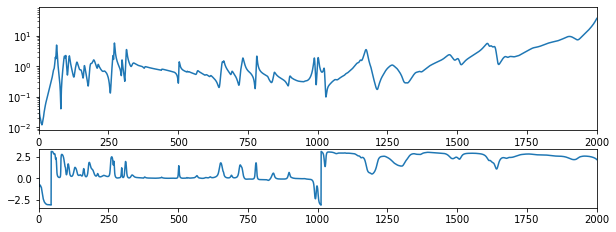

In [169]:
_out = 7
_in = 3

plt.figure(figsize = (10,5))
plt.subplot(211)
plt.semilogy(freq,np.abs(FRF[:,_out,_in]))
plt.xlim(0,2000)

plt.subplot(413)
plt.plot(freq,np.angle(FRF[:,_out,_in]))
plt.xlim(0,2000)


display(df_chn.iloc[[_out]])
display(df_imp.iloc[[_in]])


### Modal analysis
First load the data

In [235]:
Y =  FRF[:,:,4] #np.load("../data/LADISK_beam/Measurements/modal.npy",allow_pickle = True)

Y = Y.T
Y.shape

(42, 25601)

Modeshape identification using pyEMA (LSCF/LSFD)

In [236]:
a = pyEMA.Model(
    Y,
    freq,
    pol_order_high=20,
    lower = 0,
    upper = 300
    )

a.get_poles()

fn_temp, xi_temp, test_fn, test_xi = pyEMA.stabilisation(a.all_poles, a.pol_order_high, err_fn=1, err_xi=0.5)

#approx_nat_freq = [64,97,109,136,163,212]
#a.select_closest_poles(approx_nat_freq)
a.stab_chart()

H_acc, A_acc = a.get_constants(whose_poles=a,least_squares_type="old")
_modes_acc = modeshape_scaling_DP(A_acc,0)

#new_mode = unflattenFRFs(_modes_acc,Y)

100%|██████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 561.86it/s]


SHIFT + LEFT mouse button to pick a pole.
RIGHT mouse button to erase the last pick.
1. Frequency: ~61 -->	60.149997297641924 Hz	(xi = 0.0182)
2. Frequency: ~108 -->	108.55093249441524 Hz	(xi = 0.0246)
3. Frequency: ~136 -->	135.64314358848955 Hz	(xi = 0.0284)


<Figure size 432x288 with 0 Axes>

In [238]:
"""
for i in range(14):
    sen_or = df_chn[["Direction_1","Direction_2","Direction_3"]].to_numpy()[3*(i):3*(i+1)]
    sen_pos = df_chn[["Position_1","Position_2","Position_3"]].to_numpy()[3*(i)]
    sen_name = df_chn[["Name"]].to_numpy()[3*(i):3*(i+1)]
    r1 = R.from_matrix(sen_or)

    print(i+1,r1.as_euler('zyx', degrees=True))
    print("-------------")
""";

In [310]:
n_sen = pts.shape[0]
n_ax = pts.shape[1]

empty = np.zeros_like(pts,dtype = complex)

for i in range(n_sen):
    for j in range(n_ax):
        empty[i,j] = _modes_acc[(i)*3+j,1]

df = pd.read_excel(AB, sheet_name='Sensors')
new = np.zeros_like(empty,dtype = complex)

for s,angle in enumerate(df[["Orientation_1","Orientation_2","Orientation_3"]].to_numpy()):
    #R = eulerAnglesToRotationMatrix(angle*np.pi/180)
    
    r = R.from_euler('zyx', angle, degrees=True)
    rot = r.as_matrix().T
    new[s,:] = empty[s,:]@rot
    

In [255]:
ann = mode_animation(new,50, no_points=60)

mode_dict = dict()

#mode_dict["freq"] = freq[freq_sel]
mode_dict["animation_pts"] = ann
mode_dict["objects_list"] = view3D.global_acc

mode_dict["fps"] = 30

view3D.add_objects_animation(mode_dict,run_animation = True)

In [311]:
df = pd.read_excel(AB, sheet_name='Sensors')
pos_array = df[["Position_1","Position_2","Position_3"]].to_numpy()*1000

faces = np.hstack([[2, 0, 1],[2,0,13],[2,13,3],[2,3,2],[2,2,1],[2,1,5],[2,4,12],[2,12,5],[2,0,4],[2,5,11],[2,10,11],[2,10,6],[2,2,6],[2,3,7],[2,7,8],[2,8,9],[2,9,4]]).astype(np.int8)

#point_cloud = pv.PolyData(pos_array)
point_cloud1 = pv.PolyData(pos_array,faces)
pts = point_cloud1.points.copy()



actor_points = view3D.plot.add_mesh(point_cloud1,name = "meshP",render_points_as_spheres = True, color = "k",point_size = 10,clim = [-1,1], cmap="viridis",scalars = np.zeros(pts.shape[0]),style = "wireframe")
actor_points = view3D.plot.add_mesh(point_cloud1,name = "mesh",render_points_as_spheres = True, color = "k",point_size = 10,clim = [-1,1], cmap="viridis",scalars = np.zeros(pts.shape[0]),style = "points")

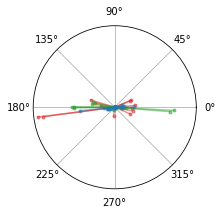

In [312]:
scale = 50

complex_plot_3D(new)
mode_dict = dict()


mode_dict["animation_pts"] = mode_animation(new,scale,no_points = 60)
mode_dict["mesh"] = point_cloud1
mode_dict["or_pts"] = pts

mode_dict["scalars"] = True
mode_dict["fps"] = 30

view3D.add_modeshape(mode_dict,run_animation = True)